<a href="https://colab.research.google.com/github/gravityeffect1/cav1/blob/main/cav1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
CLEAN_RESULTS = False

if CLEAN_RESULTS and os.path.exists("results"):
    import shutil
    shutil.rmtree("results")
os.makedirs("results", exist_ok=True)
import os, sys

print("Current working dir:", os.getcwd())
print("Files here:", os.listdir("."))


os.makedirs("data", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("Created/verified folders: data/, results/")

Current working dir: /content
Files here: ['.config', 'data', 'results', 'sample_data']
Created/verified folders: data/, results/


In [16]:
!pip -q install biopython pandas numpy matplotlib

In [17]:
seq = (
    "MSGGKYVDSEGHLYTVPIREQGNIYKPNNKAMADELSEKQVYDAHTKEIDLVNRDPKHLN"
    "DDVVKIDFEDVIAEPEGTHSFDGIWKASFTTFTVTKYWFYRLLSALFGIPMALIWGIYFA"
    "ILSFLHIWAVVPCIKSFLIEIQCISRVYSIYVHTVCDPLFEAVGKIFSNVRINLQKEI"
)

with open("data/caveolae_targets.fasta", "w") as f:
    f.write(">CAV1_HUMAN\n")
    for i in range(0, len(seq), 60):
        f.write(seq[i:i+60] + "\n")

print("Saved FASTA length:", len(seq))
print("Wrote: data/caveolae_targets.fasta")

Saved FASTA length: 178
Wrote: data/caveolae_targets.fasta


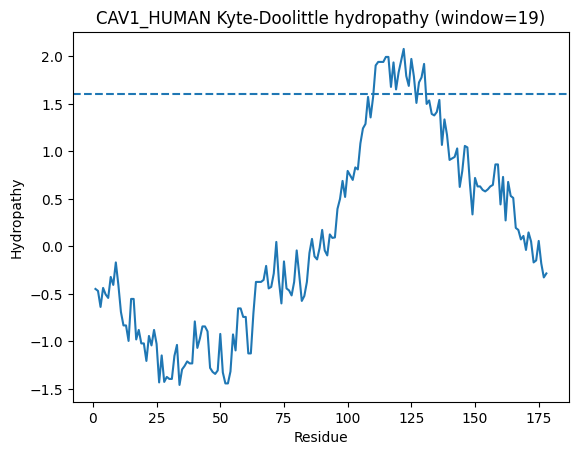

Saved: results/hydropathy.png
Saved: results/features_light.csv


,id,length,hydro_max_windowed,hydro_mean_windowed
0,CAV1_HUMAN,178,2.078947,0.074837


In [22]:
from Bio import SeqIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load sequence from FASTA
rec = next(SeqIO.parse("data/caveolae_targets.fasta", "fasta"))
pid, seq = rec.id, str(rec.seq)

# Kyte-Doolittle scale
kd = {
    "A": 1.8, "C": 2.5, "D":-3.5, "E":-3.5, "F": 2.8, "G":-0.4, "H":-3.2, "I": 4.5,
    "K":-3.9, "L": 3.8, "M": 1.9, "N":-3.5, "P":-1.6, "Q":-3.5, "R":-4.5, "S":-0.8,
    "T":-0.7, "V": 4.2, "W":-0.9, "Y":-1.3
}

vals = np.array([kd.get(a, 0.0) for a in seq], dtype=float)

def smooth(x, w=19):
    if len(x) < w:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="same")

w = 19
hydro = smooth(vals, w=w)


plt.figure()
plt.plot(np.arange(1, len(seq) + 1), hydro)
plt.axhline(1.6, linestyle="--")
plt.title(f"{pid} Kyte-Doolittle hydropathy (window={w})")
plt.xlabel("Residue")
plt.ylabel("Hydropathy")
plt.show()


print("Saved: results/hydropathy.png")
df = pd.DataFrame([{
    "id": pid,
    "length": len(seq),
    "hydro_max_windowed": float(np.max(hydro)),
    "hydro_mean_windowed": float(np.mean(hydro)),
}])

df.to_csv("results/features_light.csv", index=False)

print("Saved: results/features_light.csv")
df

In [19]:
start, end = 111, 130
print("Membrane hairpin sequence (111–130):")
print(seq[start-1:end])

Membrane hairpin sequence (111–130):
MALIWGIYFAILSFLHIWAV
